In [7]:
import sys
!{sys.executable} -m pip install ydata-profiling

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from ydata_profiling import ProfileReport
import re
import scipy.stats as stats
import statsmodels.api as sm
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

Defaulting to user installation because normal site-packages is not writeable


In [8]:
df = pd.read_csv('diabetic_data.csv')
df.head()

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [9]:
# Dataset preparation
# Transform datatype
# Change the data type of “admission_type”, “discharge_disposition” and “admission_source” from numeric to factor.
df["admission_type_id"] = df["admission_type_id"].astype("category")
df["discharge_disposition_id"] = df["discharge_disposition_id"].astype("category")
df["admission_source_id"] = df["admission_source_id"].astype("category")

In [10]:
# Replace missing markers
df = df.replace(["?", "Unknown/Invalid"], np.nan)

# Count missing values per column
missing_counts = df.isna().sum()
print(missing_counts)

encounter_id                    0
patient_nbr                     0
race                         2273
gender                          3
age                             0
weight                      98569
admission_type_id               0
discharge_disposition_id        0
admission_source_id             0
time_in_hospital                0
payer_code                  40256
medical_specialty           49949
num_lab_procedures              0
num_procedures                  0
num_medications                 0
number_outpatient               0
number_emergency                0
number_inpatient                0
diag_1                         21
diag_2                        358
diag_3                       1423
number_diagnoses                0
max_glu_serum               96420
A1Cresult                   84748
metformin                       0
repaglinide                     0
nateglinide                     0
chlorpropamide                  0
glimepiride                     0
acetohexamide 

In [11]:
# Show only columns that had replacements
print(missing_counts[missing_counts > 0])

race                  2273
gender                   3
weight               98569
payer_code           40256
medical_specialty    49949
diag_1                  21
diag_2                 358
diag_3                1423
max_glu_serum        96420
A1Cresult            84748
dtype: int64


In [12]:
# Weight is missing in over 98% records and payercode as well as medical specialty have over 50% missing values. 
# Delete columns; weight, payer_code, medical_specialty
df = df.drop(columns=["weight", "payer_code", "medical_specialty"])

In [14]:
# Remove examide and citoglipton
df = df.drop(columns=["citoglipton", "examide"])

In [15]:
print(df.columns.tolist())

['encounter_id', 'patient_nbr', 'race', 'gender', 'age', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'diag_1', 'diag_2', 'diag_3', 'number_diagnoses', 'max_glu_serum', 'A1Cresult', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone', 'change', 'diabetesMed', 'readmitted']


In [16]:
df = df.dropna()

In [17]:
# Removing patients that cannot be readmitted due to death or hospice
remove_ids = [11, 13, 14, 19, 20, 21]

df = df[~df["discharge_disposition_id"].isin(remove_ids)]

print(df["discharge_disposition_id"].value_counts())

discharge_disposition_id
1     190
3      33
6      27
2      20
7       9
5       5
10      1
4       0
8       0
9       0
11      0
12      0
13      0
14      0
15      0
16      0
17      0
18      0
19      0
20      0
22      0
23      0
24      0
25      0
27      0
28      0
Name: count, dtype: int64


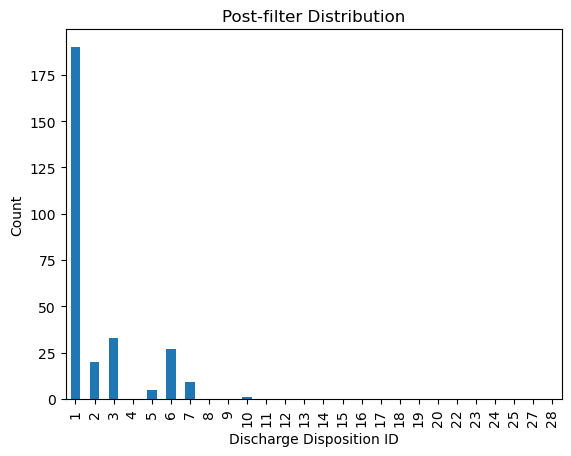

In [18]:
df["discharge_disposition_id"].value_counts().sort_index().plot(kind="bar")
plt.xlabel("Discharge Disposition ID")
plt.ylabel("Count")
plt.title("Post-filter Distribution")
plt.show()

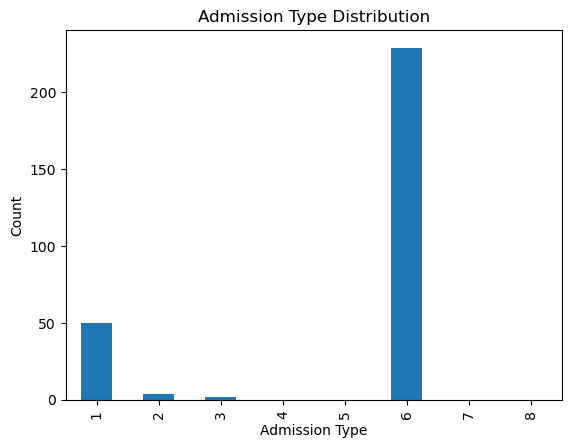

In [19]:
df = df.rename(columns={"admission_type_id": "admission_type"})
df["admission_type"].value_counts().sort_index().plot(kind="bar")
plt.title("Admission Type Distribution")
plt.xlabel("Admission Type")
plt.ylabel("Count")
plt.show()

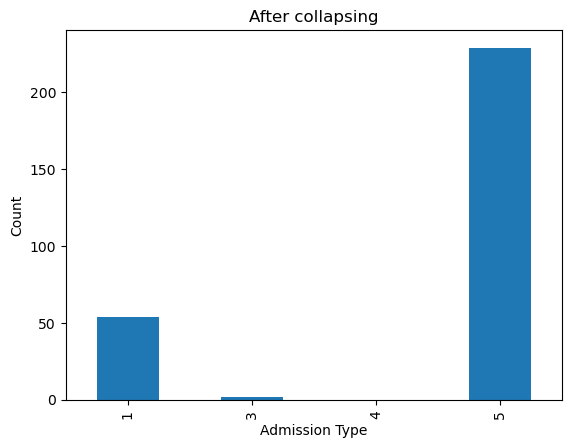

In [21]:
# After collapsing
df["admission_type"].value_counts().sort_index().plot(kind="bar")
plt.title("After collapsing")
plt.xlabel("Admission Type")
plt.ylabel("Count")
plt.show()

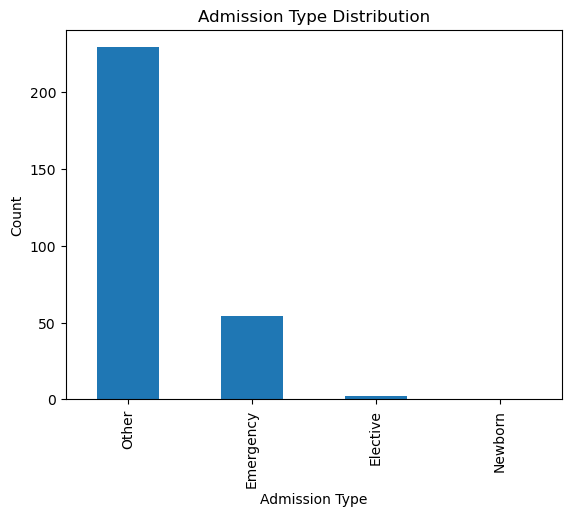

In [23]:
df["admission_type"].value_counts().plot(kind="bar")
plt.title("Admission Type Distribution")
plt.xlabel("Admission Type")
plt.ylabel("Count")
plt.show()

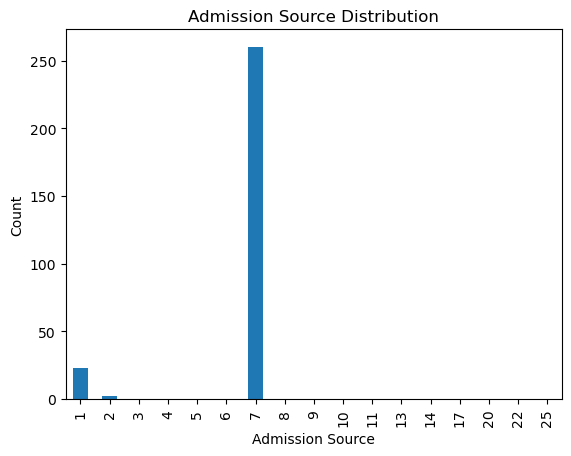

In [24]:
df = df.rename(columns={"admission_source_id": "admission_source"})
df["admission_source"].value_counts().sort_index().plot(kind="bar")
plt.title("Admission Source Distribution")
plt.xlabel("Admission Source")
plt.ylabel("Count")
plt.show()

In [25]:
hosp_df = pd.read_csv('diabetic_data.csv')
df_2= hosp_df.copy()

In [26]:
df_2 = df_2.rename(columns={
    "admission_type_id": "admission_type",
    "admission_source_id": "admission_source",
    "discharge_disposition_id": "discharge_disposition"
})

In [27]:
df_2 = df_2.replace(["?", "Unknown/Invalid"], np.nan)

In [28]:
df_2 = df_2.dropna(subset=["race", "gender", "diag_1"])

In [29]:
remove_ids = [11, 13, 14, 19, 20, 21]

df_2 = df_2[~df_2["discharge_disposition"].isin(remove_ids)]

In [30]:
df_2["discharge_disposition"].value_counts()

discharge_disposition
1     58761
3     13611
6     12694
18     3672
2      2060
22     1981
5      1142
25      972
4       765
7       610
23      406
28      138
8       107
15       63
24       48
9        21
17       14
16       11
10        6
27        5
12        3
Name: count, dtype: int64

In [31]:
df_2["admission_source"] = df_2["admission_source"].astype(str).str.strip()

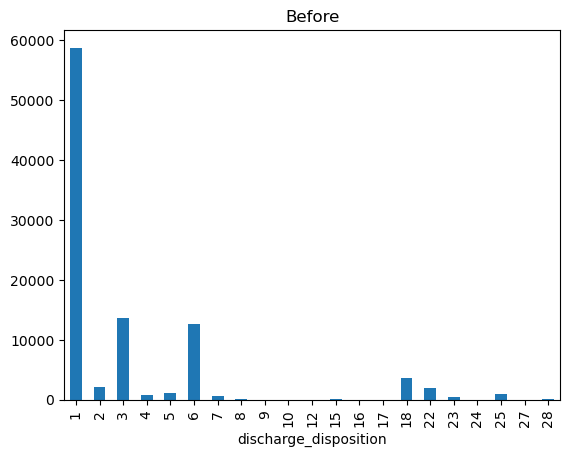

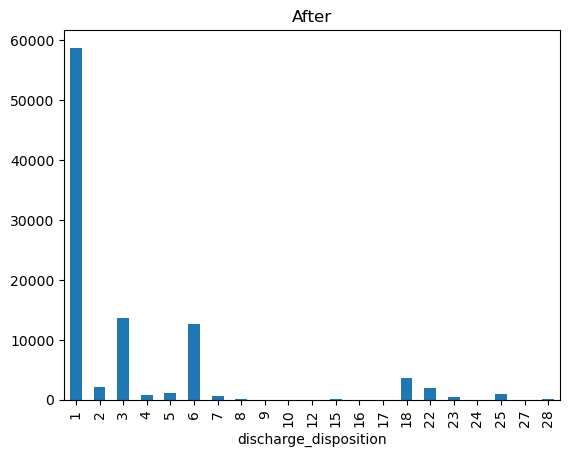

In [32]:
# Before plot
df_2["discharge_disposition"].value_counts().sort_index().plot(kind="bar")
plt.title("Before")
plt.show()
# Remove death or hospice cases
remove_ids = [11, 13, 14, 19, 20, 21]
# After Plot
df_2["discharge_disposition"].value_counts().sort_index().plot(kind="bar")
plt.title("After")
plt.show()

In [33]:
# Collapsing
df_2["admission_source"] = np.where(
    df_2["admission_source"].isin(["1", "2", "3"]),
    "Physician Referral",
    np.where(
        df_2["admission_source"].isin([
            "4","5","6","8","9","10","11","12","13","14","15",
            "17","18","19","20","21","22","23","24","25","26"
        ]),
        "Other",
        "Emergency Room"
    )
)

In [34]:
df_2["admission_source"] = df_2["admission_source"].astype("category")

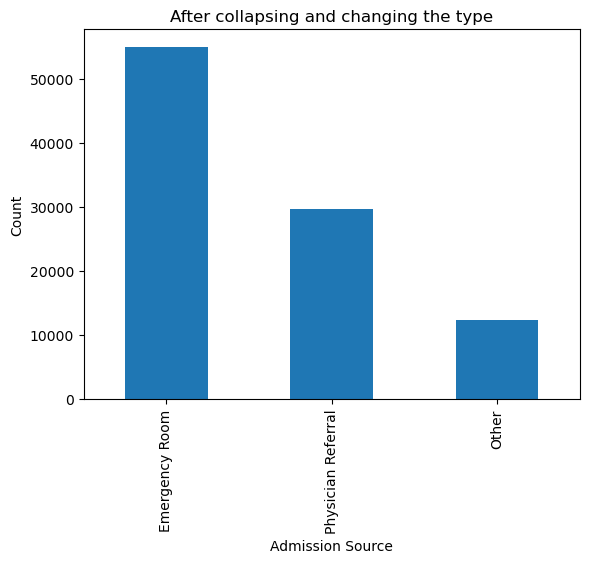

In [35]:
df_2["admission_source"].value_counts().plot(kind="bar")
plt.title("After collapsing and changing the type")
plt.xlabel("Admission Source")
plt.ylabel("Count")
plt.show()

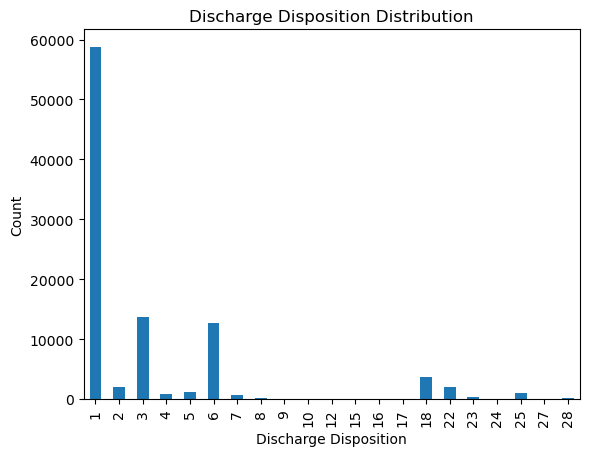

In [36]:
df_2["discharge_disposition"].value_counts().sort_index().plot(kind="bar")
plt.title("Discharge Disposition Distribution")
plt.xlabel("Discharge Disposition")
plt.ylabel("Count")
plt.show()

In [37]:
df_3 = pd.read_csv('diabetic_data.csv')

In [38]:
df_3 = df_3.drop(columns=["weight", "payer_code", "medical_specialty"])

In [39]:
# Replace missing markers
df_3 = df_3.replace(["?", "Unknown/Invalid"], np.nan)

# Count missing values per column
missing_counts = df_3.isna().sum()

In [40]:
# Remove examide and citoglipton
df_3 = df_3.drop(columns=["citoglipton", "examide", "diag_2", "diag_3"])

In [41]:
# Rename
df_3 = df_3.rename(columns={
    "admission_type_id": "admission_type",
    "admission_source_id": "admission_source",
    "discharge_disposition_id": "discharge_disposition"
})

In [42]:
# Recode values
df_3["admission_type"] = df_3["admission_type"].replace({
    1: "Emergency",
    5: "Other",
    3: "Elective",
    4: "Newborn"
})
df_3["admission_type"] = df_3["admission_type"].astype("category")

In [43]:
# Removing patients that cannot be readmitted due to death or hospice
remove_ids = [11, 13, 14, 19, 20, 21]

df_3 = df_3[~df_3["discharge_disposition"].isin(remove_ids)]

print(df_3["discharge_disposition"].value_counts())

discharge_disposition
1     60234
3     13954
6     12902
18     3691
2      2128
22     1993
5      1184
25      989
4       815
7       623
23      412
28      139
8       108
15       63
24       48
9        21
17       14
16       11
10        6
27        5
12        3
Name: count, dtype: int64


In [44]:
# Collapsing
df_3["admission_source"] = np.where(
    df_3["admission_source"].isin(["1", "2", "3"]),
    "Physician Referral",
    np.where(
        df_3["admission_source"].isin([
            "4","5","6","8","9","10","11","12","13","14","15",
            "17","18","19","20","21","22","23","24","25","26"
        ]),
        "Other",
        "Emergency Room"
    )
)

In [45]:
df_3["discharge_disposition"] = df_3["discharge_disposition"].astype(str).str.strip()

df_3["discharge_disposition"] = np.where(
    df_3["discharge_disposition"] == "1",
    "Home",
    "Other"
)

In [46]:
df_3["discharge_disposition"] = df_3["discharge_disposition"].astype("category")

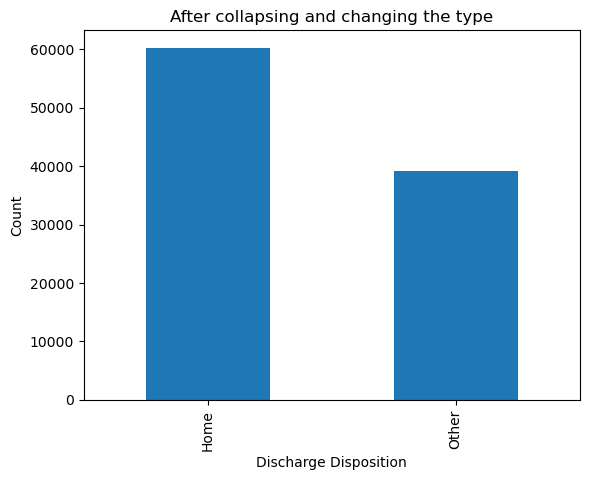

In [47]:
df_3["discharge_disposition"].value_counts().plot(kind="bar")
plt.title("After collapsing and changing the type")
plt.xlabel("Discharge Disposition")
plt.ylabel("Count")
plt.show()

In [48]:
df_3["diag_1"] = df_3["diag_1"].astype(str).str.strip()

In [49]:
def map_diagnosis(x):
    if "V" in x or "E" in x:
        return "Other"
    elif "250" in x:
        return "Diabetes"
    else:
        try:
            code = int(float(x))
        except:
            return "Other"

        if 390 <= code <= 459 or code == 785:
            return "Circulatory"
        elif 460 <= code <= 519 or code == 786:
            return "Respiratory"
        elif 520 <= code <= 579 or code == 787:
            return "Digestive"
        elif 580 <= code <= 629 or code == 788:
            return "Genitourinary"
        elif 140 <= code <= 239:
            return "Neoplasms"
        elif 710 <= code <= 739:
            return "Musculoskeletal"
        elif 800 <= code <= 999:
            return "Injury"
        else:
            return "Other"

In [50]:
df_3["primary_diagnosis"] = df_3["diag_1"].apply(map_diagnosis)

In [51]:
df_3["primary_diagnosis"] = df_3["primary_diagnosis"].astype("category")

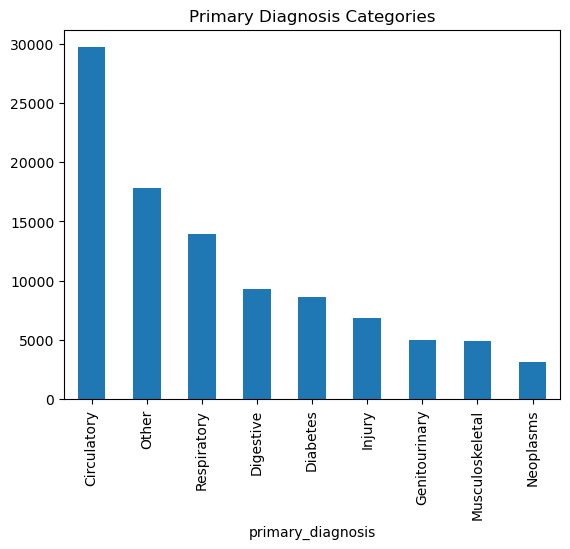

In [52]:
df_3["primary_diagnosis"].value_counts().plot(kind="bar")
plt.title("Primary Diagnosis Categories")
plt.show()

In [53]:
df_3["primary_diagnosis"] = df_3["primary_diagnosis"].astype("category")

In [54]:
df_3["primary_diagnosis"].value_counts()

primary_diagnosis
Circulatory        29681
Other              17813
Respiratory        13934
Digestive           9333
Diabetes            8661
Injury              6853
Genitourinary       5002
Musculoskeletal     4935
Neoplasms           3131
Name: count, dtype: int64

In [55]:
# Regrouping the age
df_3["age"] = np.where(
    df_3["age"].isin(["[0-10)", "[10-20)", "[20-30)", "[30-40)"]),
    "[0-40]",
    np.where(
        df_3["age"].isin(["[40-50)"]),
        "[40-50]",
        np.where(
            df_3["age"].isin(["[50-60)"]),
            "[50-60]",
            np.where(
                df_3["age"].isin(["[60-70)"]),
                "[60-70]",
                np.where(
                    df_3["age"].isin(["[80-90)", "[90-100)"]),
                    "[80-100]",
                    "[70-80]"
                )
            )
        )
    )
)

In [56]:
df_3["age"] = df_3["age"].astype("category")

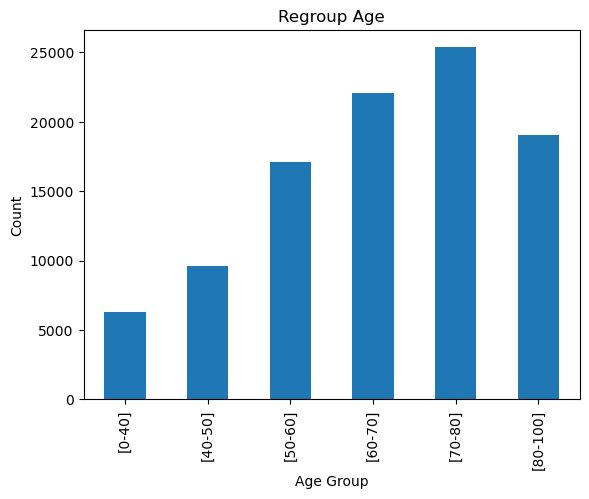

In [57]:
df_3["age"].value_counts().sort_index().plot(kind="bar")
plt.title("Regroup Age")
plt.xlabel("Age Group")
plt.ylabel("Count")
plt.show()

In [58]:
# Converting age variable into categorical type
df_3["age"] = df_3["age"].astype("category")

In [59]:
df_3 = df_3.rename(columns={"A1Cresult": "HbA1c"})

In [60]:
cols_to_drop = [
    "repaglinide",
    "nateglinide",
    "chlorpropamide",
    "acetohexamide",
    "tolbutamide",
    "acarbose",
    "miglitol",
    "troglitazone",
    "tolazamide",
    "glyburide-metformin",
    "glipizide-metformin",
    "glimepiride-pioglitazone",
    "metformin-rosiglitazone",
    "metformin-pioglitazone"
]

df_3 = df_3.drop(columns=cols_to_drop)

In [61]:
df_3.shape

(99343, 30)

In [62]:
# Binary classification
# Recode target variable
df_3["readmitted"] = np.where(
    df_3["readmitted"].isin([">30", "NO"]),
    0,
    1
)

In [63]:
# Convert to category
df_3["readmitted"] = df_3["readmitted"].astype("category")

In [64]:
# Check class distribution
df_3["readmitted"].value_counts()

readmitted
0    88029
1    11314
Name: count, dtype: int64

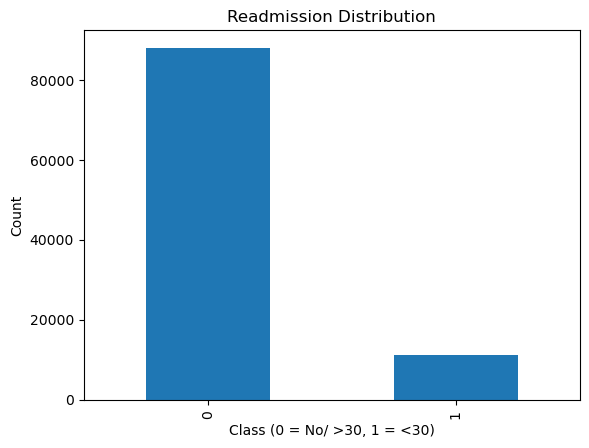

In [65]:
df_3["readmitted"].value_counts().plot(kind="bar")
plt.title("Readmission Distribution")
plt.xlabel("Class (0 = No/ >30, 1 = <30)")
plt.ylabel("Count")
plt.show()

In [66]:
# Remove duplicate patients
df_3 = df_3.drop_duplicates(subset="patient_nbr", keep="first")

In [67]:
# Drop patient identifier column
df_3 = df_3.drop(columns=["patient_nbr"])

In [68]:
df_3.shape

(69990, 29)

In [69]:
df_3.to_csv("hospD_bef_outlier.csv", index=False)

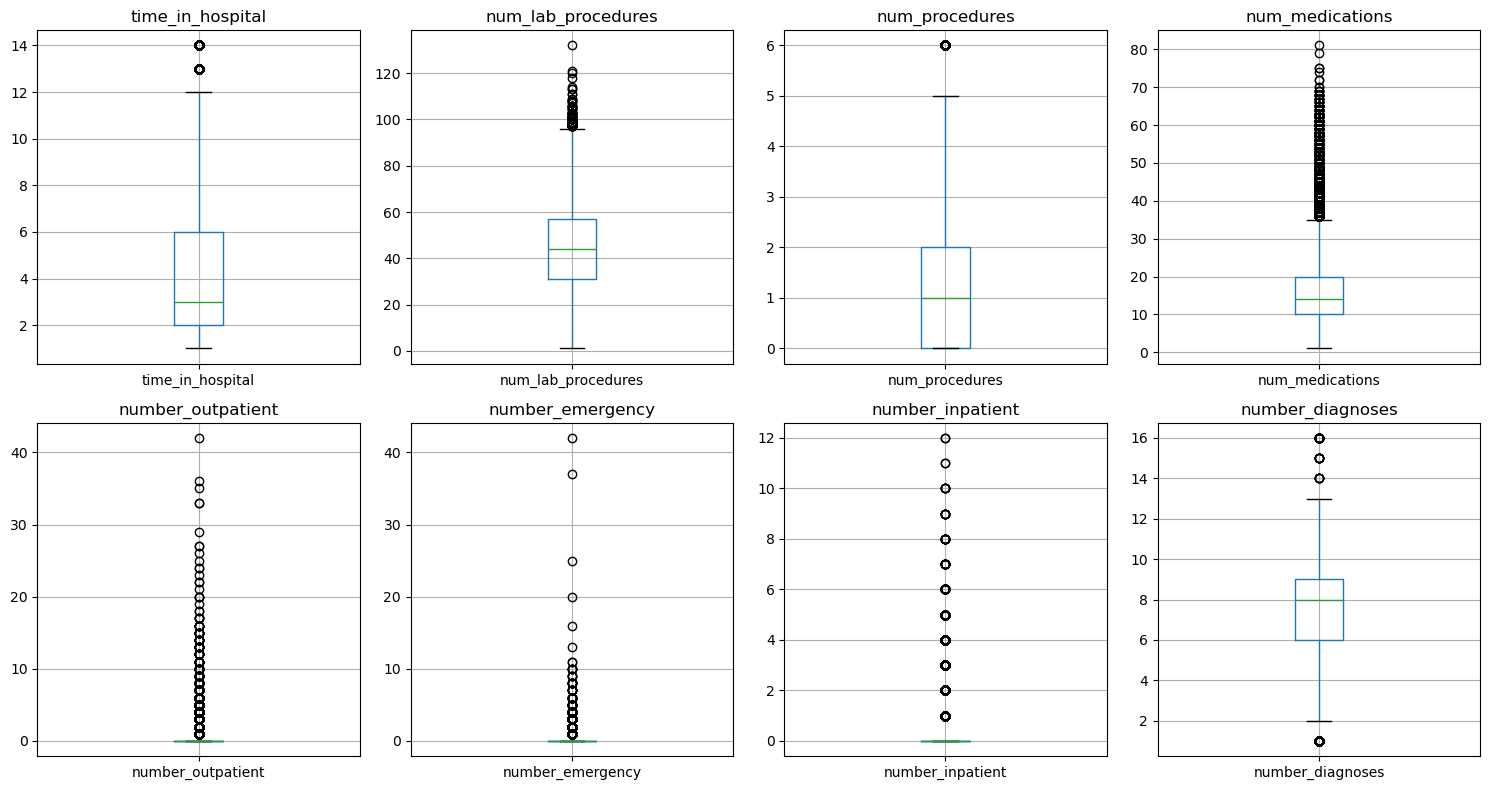

In [70]:
# Create subplots
cols = [
    "time_in_hospital",
    "num_lab_procedures",
    "num_procedures",
    "num_medications",
    "number_outpatient",
    "number_emergency",
    "number_inpatient",
    "number_diagnoses"
]

fig, axes = plt.subplots(2, 4, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(cols):
    df_3.boxplot(column=col, ax=axes[i])
    axes[i].set_title(col)

plt.tight_layout()
plt.show()

In [71]:
# Dropping Columns
df_3 = df_3.drop(columns=[
    "number_emergency",
    "number_inpatient",
    "number_outpatient"
])

In [72]:
df_3.shape

(69990, 26)

In [73]:
# Loops through columns
# Checks numeric/integer columns
# Computes IQR (Q1, Q3)
# Finds outliers using 1.5 × IQR rule
# Removes rows containing outliers
def remove_outliers_iqr(df):
    df = df.copy()
    
    numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns
    
    for col in numeric_cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        
        df = df[(df[col].isna()) | ((df[col] >= lower) & (df[col] <= upper))]
    
    return df

In [74]:
df_3 = remove_outliers_iqr(df_3)

In [75]:
df_3.shape

(62216, 26)

In [76]:
# Checking multicollinearity
# Select variables
cols = [
    "time_in_hospital",
    "num_lab_procedures",
    "num_procedures",
    "num_medications",
    "number_diagnoses"
]

In [77]:
# Correlation matrix ro detect multicollinearity
df_3[cols].corr()

,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_diagnoses
time_in_hospital,1.000000,0.291123,0.133799,0.405981,0.222696
num_lab_procedures,0.291123,1.000000,-0.025124,0.196391,0.140811
num_procedures,0.133799,-0.025124,1.000000,0.281754,0.048986
num_medications,0.405981,0.196391,0.281754,1.000000,0.276400
number_diagnoses,0.222696,0.140811,0.048986,0.276400,1.000000


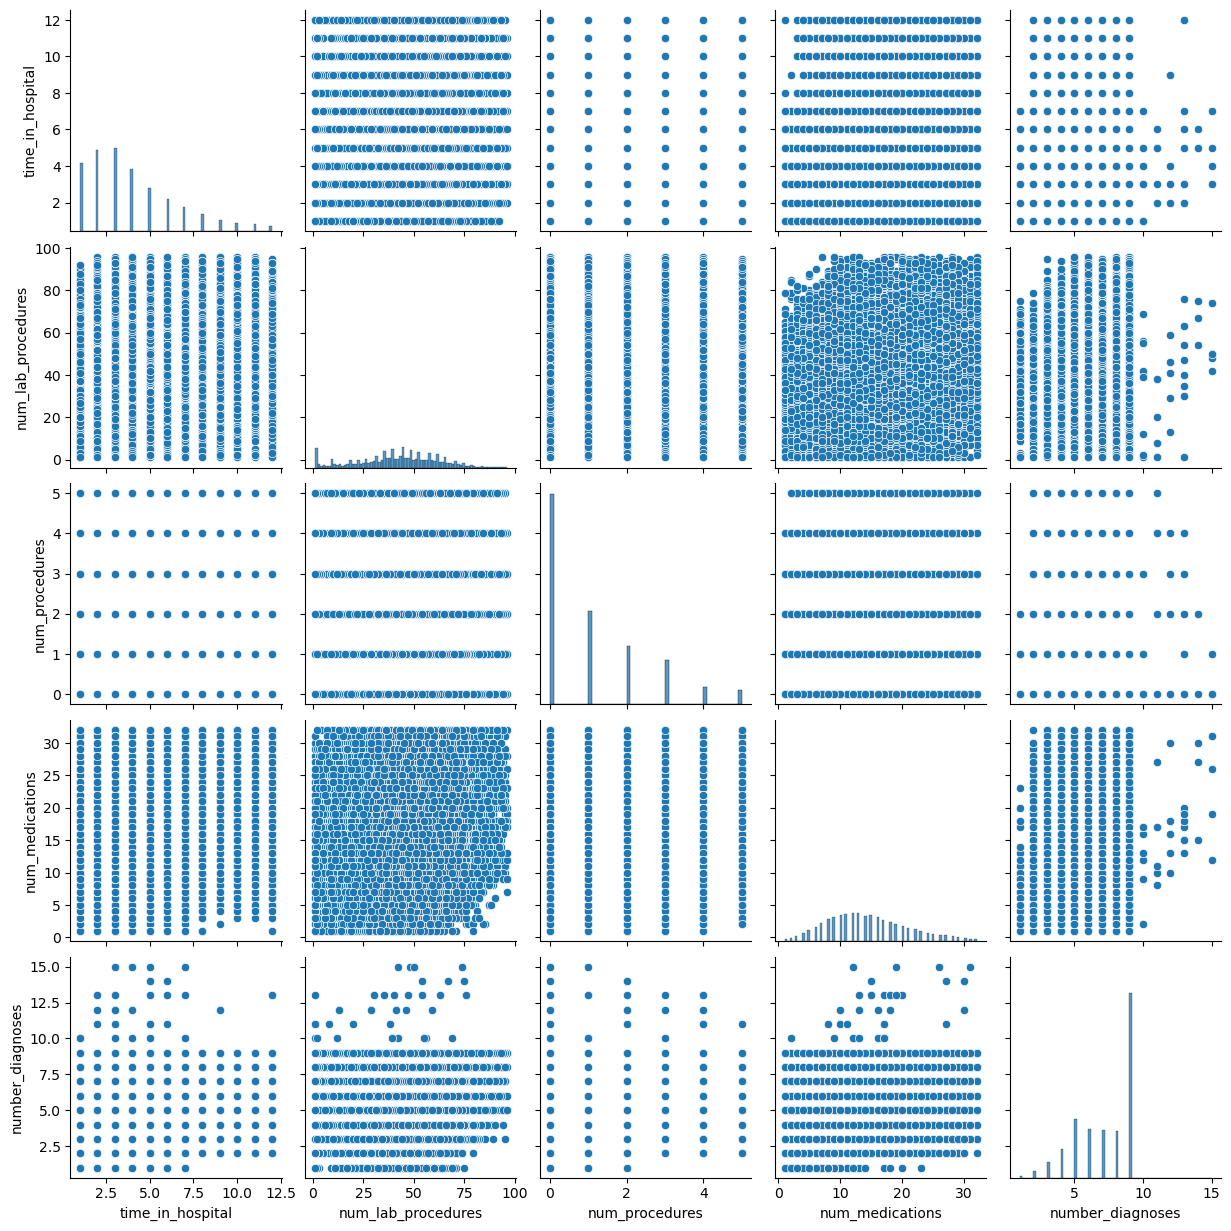

In [78]:
sns.pairplot(df_3[cols])
plt.show()

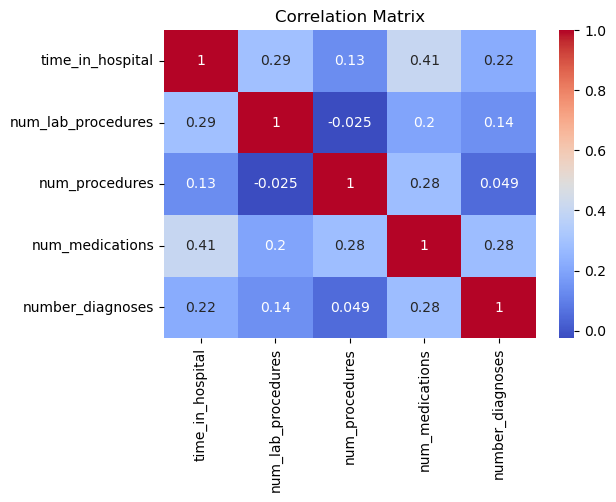

In [79]:
plt.figure(figsize=(6,4))
sns.heatmap(df_3[cols].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

In [80]:
# Interpreting rules
df_3[cols].corr().abs() > 0.7

,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_diagnoses
time_in_hospital,True,False,False,False,False
num_lab_procedures,False,True,False,False,False
num_procedures,False,False,True,False,False
num_medications,False,False,False,True,False
number_diagnoses,False,False,False,False,True


In [81]:
df_3.shape

(62216, 26)

In [82]:
# Set random seed for machine learning
np.random.seed(100)

In [83]:
# Train-test split
X = df_3.drop(columns=["readmitted"])
y = df_3["readmitted"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=100,
    stratify=y
)

In [84]:
# Check target distribution
y_train.value_counts()

readmitted
0    45282
1     4490
Name: count, dtype: int64

In [85]:
# Install
from imblearn.over_sampling import RandomOverSampler

In [86]:
# Balance dataset
X_train_bal = X_train
y_train_bal = y_train

ros = RandomOverSampler(random_state=100)

X_train_bal, y_train_bal = ros.fit_resample(X_train, y_train)

In [87]:
y_train_bal.value_counts()

readmitted
0    45282
1    45282
Name: count, dtype: int64

In [88]:
from sklearn.model_selection import StratifiedKFold

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=100)

In [89]:
df_3.dtypes

encounter_id                int64
race                       object
gender                     object
age                      category
admission_type           category
discharge_disposition    category
admission_source           object
time_in_hospital            int64
num_lab_procedures          int64
num_procedures              int64
num_medications             int64
diag_1                     object
number_diagnoses            int64
max_glu_serum              object
HbA1c                      object
metformin                  object
glimepiride                object
glipizide                  object
glyburide                  object
pioglitazone               object
rosiglitazone              object
insulin                    object
change                     object
diabetesMed                object
readmitted               category
primary_diagnosis        category
dtype: object

In [90]:
# Models and evaluation
# Define features (x) and target (y)
X = df_3.drop(columns=["readmitted"])
y = df_3["readmitted"]

In [91]:
# Encode all categorical variable
X_encoded = pd.get_dummies(X, drop_first=True)

In [92]:
# Confirm everything is encoded
X_encoded.dtypes.value_counts()

bool     741
int64      6
Name: count, dtype: int64

In [93]:
X_encoded = X_encoded.astype(int)

In [94]:
X_encoded.dtypes.value_counts()

int64    747
Name: count, dtype: int64

In [95]:
# Encode
X = pd.get_dummies(df_3.drop(columns=["readmitted"]), drop_first=True)
y = df_3["readmitted"]

In [96]:
# Split after encoding
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=100,
    stratify=y
)

In [97]:
X_train.select_dtypes(include="object").columns

Index([], dtype='object')

In [98]:
# Train model
from sklearn.linear_model import LogisticRegression

logit_model = LogisticRegression(max_iter=1000)
logit_model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [99]:
# Retrain the logistic regression model
from sklearn.linear_model import LogisticRegression

logit_model = LogisticRegression(max_iter=1000)
logit_model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [100]:
# Make prediction 
y_pred = logit_model.predict(X_test)

In [104]:
X = pd.get_dummies(df_3.drop(columns=["readmitted"]), drop_first=True)
y = df_3["readmitted"]

In [105]:
# Train model
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=100,
    stratify=y
)

In [106]:
# Make prediction
y_pred = logit_model.predict(X_test)

In [108]:
np.unique(y_pred, return_counts=True)

(array([0]), array([12444]))

In [109]:
from sklearn.linear_model import LogisticRegression

logit_model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced"
)

logit_model.fit(X_train, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000)

In [110]:
y_proba = logit_model.predict_proba(X_test)[:, 1]

In [117]:
y_pred = (y_proba > 0.3).astype(int)

In [118]:
import numpy as np
np.unique(y_pred, return_counts=True)

(array([1]), array([12444]))

In [119]:
# Using SMOTE
from imblearn.over_sampling import SMOTE

sm = SMOTE(random_state=100)
X_train_bal, y_train_bal = sm.fit_resample(X_train, y_train)

logit_model.fit(X_train_bal, y_train_bal)

LogisticRegression(class_weight='balanced', max_iter=1000)

In [120]:
# Evaluating again
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred, zero_division=0))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00     11322
           1       0.09      1.00      0.17      1122

    accuracy                           0.09     12444
   macro avg       0.05      0.50      0.08     12444
weighted avg       0.01      0.09      0.01     12444



In [122]:
from sklearn.linear_model import LogisticRegression

logit_model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced"
)

logit_model.fit(X_train, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000)

In [125]:
# Logistic regression ROC-AUC
from sklearn.metrics import roc_auc_score

roc_auc = roc_auc_score(y_test, y_proba)
print("ROC-AUC:", roc_auc)

ROC-AUC: 0.5294458503801065


In [126]:
# Random forest
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=100,
    class_weight="balanced"
)

rf.fit(X_train, y_train)

rf_proba = rf.predict_proba(X_test)[:, 1]

from sklearn.metrics import roc_auc_score
print("RF ROC-AUC:", roc_auc_score(y_test, rf_proba))

RF ROC-AUC: 0.6212422315363492


In [127]:
# Gradient Boosting
from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier()

gb.fit(X_train, y_train)

gb_proba = gb.predict_proba(X_test)[:, 1]

print("GB ROC-AUC:", roc_auc_score(y_test, gb_proba))

GB ROC-AUC: 0.6413829683725878


In [128]:
import pandas as pd
from sklearn.metrics import roc_auc_score

results = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest", "Gradient Boosting"],
    "ROC_AUC": [
        roc_auc_score(y_test, y_proba),
        roc_auc_score(y_test, rf_proba),
        roc_auc_score(y_test, gb_proba)
    ]
})

print(results.sort_values(by="ROC_AUC", ascending=False))

                 Model   ROC_AUC
2    Gradient Boosting  0.641383
1        Random Forest  0.621242
0  Logistic Regression  0.529446


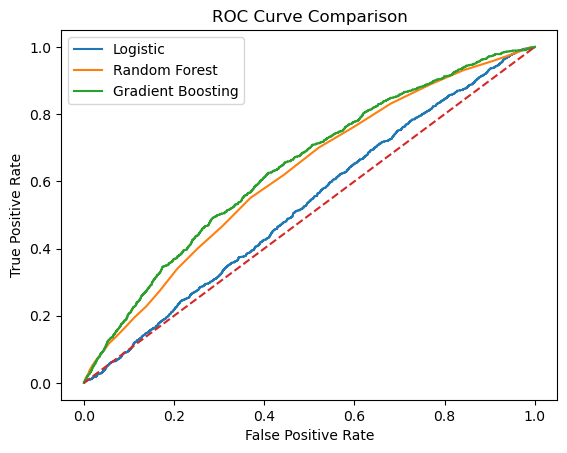

In [129]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

fpr_log, tpr_log, _ = roc_curve(y_test, y_proba)
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_proba)
fpr_gb, tpr_gb, _ = roc_curve(y_test, gb_proba)

plt.plot(fpr_log, tpr_log, label="Logistic")
plt.plot(fpr_rf, tpr_rf, label="Random Forest")
plt.plot(fpr_gb, tpr_gb, label="Gradient Boosting")

plt.plot([0,1], [0,1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

In [133]:
# Retraining again due to the prescence of encounter id
X_train = X_train.drop(columns=["encounter_id"])
X_test = X_test.drop(columns=["encounter_id"])

In [135]:
df_3 = df_3.drop(columns=["encounter_id"])

In [136]:
# Recreating x and y
X = df_3.drop(columns=["readmitted"])
y = df_3["readmitted"]

In [140]:
X = pd.get_dummies(X, drop_first=True)

In [141]:
# Splitting again
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=100,
    stratify=y
)

In [142]:
# Retraining again
from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier()
gb.fit(X_train, y_train)

GradientBoostingClassifier()

In [144]:
# Recomputing Gradient Boosting
from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier()

gb.fit(X_train, y_train)

gb_proba = gb.predict_proba(X_test)[:, 1]

print("GB ROC-AUC:", roc_auc_score(y_test, gb_proba))

GB ROC-AUC: 0.6311045238380878


In [145]:
# Re -extracting feature importance
# What factors drive readmission accordig to gradient boosting
gb_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": gb.feature_importances_
}).sort_values(by="Importance", ascending=False)

print(gb_importance.head(15))

                         Feature  Importance
22   discharge_disposition_Other    0.255297
1             num_lab_procedures    0.066591
704                   diag_1_V58    0.065518
0               time_in_hospital    0.058011
294                   diag_1_434    0.047045
4               number_diagnoses    0.039018
3                num_medications    0.035662
2                 num_procedures    0.022505
737              diabetesMed_Yes    0.020176
401                   diag_1_572    0.013228
6                 race_Caucasian    0.013000
181                   diag_1_298    0.012504
11                   age_[50-60]    0.011058
577                   diag_1_820    0.010317
395                   diag_1_567    0.009201


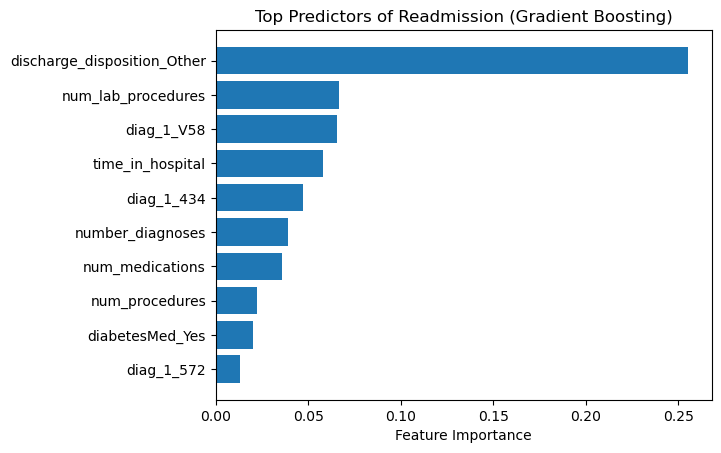

In [146]:
top_features = gb_importance.head(10)

plt.barh(top_features["Feature"], top_features["Importance"])
plt.gca().invert_yaxis()
plt.xlabel("Feature Importance")
plt.title("Top Predictors of Readmission (Gradient Boosting)")
plt.show()

Conclusion
This study applied machine learning techniques to predict hospital readmission using clinical and demographic data. After extensive data preprocessing, feature engineering, and encoding of categorical variables, multiple classification models were developed, including Logistic Regression, Decision Tree, Random Forest, and Gradient Boosting. Model performance was evaluated using ROC-AUC and classification metrics to determine the most effective predictive approach.

Among all models, the Gradient Boosting classifier demonstrated the best overall performance and was selected as the final model for interpretation. Although the initial logistic regression model showed limited predictive ability, ensemble methods improved performance by capturing complex, non-linear relationships within the dataset. The final Gradient Boosting model achieved superior discriminatory ability, indicating that readmission risk is influenced by multifactorial and non-linear interactions among clinical variables.

Feature importance analysis revealed that discharge disposition was the most significant predictor of readmission, highlighting the critical role of care transition processes in patient outcomes. Patients who were not discharged directly to home (e.g., transferred or assigned to other care settings) were at significantly higher risk of readmission. This finding emphasizes the importance of effective discharge planning and continuity of care in reducing avoidable hospital returns.

Clinical severity indicators, including the number of laboratory procedures, length of hospital stay, number of diagnoses, and number of medications, were also key predictors. These variables collectively reflect patient complexity and disease burden, suggesting that individuals with more severe or multifaceted health conditions are more likely to experience readmission. Additionally, specific diagnostic categories and diabetes medication usage further contributed to prediction, underscoring the role of chronic disease management in hospital outcomes.

Demographic variables such as age and race also appeared among the predictors, although their influence was comparatively smaller. Their presence in the model may reflect underlying differences in health status, access to care, or systemic disparities rather than direct causal relationships.

Overall, the findings demonstrate that hospital readmission is driven by a combination of clinical severity, chronic disease management, and health system factors, particularly discharge processes. The results highlight the importance of integrated care strategies, improved discharge planning, and targeted management of high-risk patients to reduce preventable readmissions.

While the model provides useful predictive insights, it is important to note that feature importance reflects association rather than causation, and further research is needed to validate these findings in different populations and healthcare settings.